# Venmito Exploratory Data Analysis

Consumes the conformed output of `data_cleaning.ipynb` (`data_clean/`) and derives
insights about clients, promotions, stores and transfers.

**Sections**
1. Setup and load
2. Who are our clients?
3. Promotions — who has what, and how do we turn "No" into "Yes"?
4. Stores and items
5. Transfers
6. Cross-dataset view
7. Statistical tests
8. Headline findings

Flagged rows (`is_clean == False`) are excluded from revenue and behavioural metrics
and analysed separately in §5.3 — they are the fraud signal, not noise.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.dates import MonthLocator, DateFormatter

CLEAN = os.environ.get("VENMITO_CLEAN", "data_clean")
if not os.path.isdir(CLEAN) and os.path.isdir("../data_clean"):
    CLEAN = "../data_clean"
if not os.path.isdir(CLEAN):
    raise FileNotFoundError(
        f"{CLEAN!r} not found -- run data_cleaning.ipynb first; it writes the conformed CSVs.")

people     = pd.read_csv(f"{CLEAN}/people.csv", parse_dates=["dob"])
promotions = pd.read_csv(f"{CLEAN}/promotions.csv", parse_dates=["promotion_date"])
items      = pd.read_csv(f"{CLEAN}/transaction_items.csv", parse_dates=["date"])
transfers  = pd.read_csv(f"{CLEAN}/transfers.csv", parse_dates=["date"])
outages    = pd.read_csv(f"{CLEAN}/transfers_outage_dates.csv", parse_dates=["date"])

people["devices"] = people["devices"].fillna("").map(
    lambda s: frozenset(filter(None, s.split("|"))))
for df in (people, promotions, items, transfers):
    for c in ("person_id", "sender_id", "recipient_id", "canonical_id"):
        if c in df:
            df[c] = df[c].astype("Int64")

print(f"people     {len(people):>5}   promotions {len(promotions):>5}")
print(f"items      {len(items):>5}   transfers  {len(transfers):>5}")

people      1002   promotions   236
items        360   transfers    614


In [2]:
# ---- chart styling -------------------------------------------------------
# Categorical hues assigned in fixed order, never cycled. Sequential = one hue.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA = SERIES[0], SERIES[1], SERIES[2]
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#256abf", "#184f95", "#0d366b"]
BLUE_CMAP = mpl.colors.LinearSegmentedColormap.from_list("venmito_blue", SEQ)
SURFACE, INK, INK_2, INK_3 = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8985"
GOOD, BAD = "#008300", "#e34948"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#dcdbd6", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#ebeae6", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "axes.labelsize": 10,
    "axes.titlesize": 12, "axes.titleweight": "600", "axes.titlelocation": "left",
    "axes.titlepad": 10, "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "font.size": 10,
})

def money(x, _=None):
    return f"${x:,.0f}"

def titled(ax, title, subtitle=None):
    ax.set_title(title, pad=24 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.015, subtitle, transform=ax.transAxes, fontsize=9,
                color=INK_3, va="bottom")

def bar_labels(ax, bars, fmt="{:,.0f}", pad=0.01, horizontal=True):
    """Direct-label the marks so identity never depends on reading an axis."""
    span = (ax.get_xlim()[1] if horizontal else ax.get_ylim()[1])
    for b in bars:
        v = b.get_width() if horizontal else b.get_height()
        if horizontal:
            ax.text(v + span * pad, b.get_y() + b.get_height() / 2, fmt.format(v),
                    va="center", ha="left", fontsize=9, color=INK_2)
        else:
            ax.text(b.get_x() + b.get_width() / 2, v + span * pad, fmt.format(v),
                    ha="center", va="bottom", fontsize=9, color=INK_2)

print("style ready")

style ready


## 2. Who are our clients?

In [3]:
people["age"] = ((pd.Timestamp("2024-04-30") - people["dob"]).dt.days / 365.25).round(1)
clients = people[~people["is_synthetic"]].copy()          # exclude the planted entity

print(f"real clients: {len(clients)}   synthetic excluded: {people['is_synthetic'].sum()}")
print(f"\nage: median {clients['age'].median():.0f}, range {clients['age'].min():.0f}-{clients['age'].max():.0f}")
print("\nby country:")
print(clients["country"].value_counts().to_string())
print("\ndevice adoption:")
dev = pd.Series({d: clients["devices"].map(lambda s: d in s).sum()
                 for d in ("Android", "Iphone", "Desktop")}).sort_values(ascending=False)
print(dev.to_string())
print(f"\ndevices per client: mean {clients['devices'].map(len).mean():.2f}")

real clients: 1000   synthetic excluded: 2

age: median 32, range 16-81

by country:
country
USA               704
Canada            157
United Kingdom     71
France             42
Spain              26

device adoption:
Iphone     578
Desktop    567
Android    559

devices per client: mean 1.70


findfont: Failed to find font weight 600, now using 700.


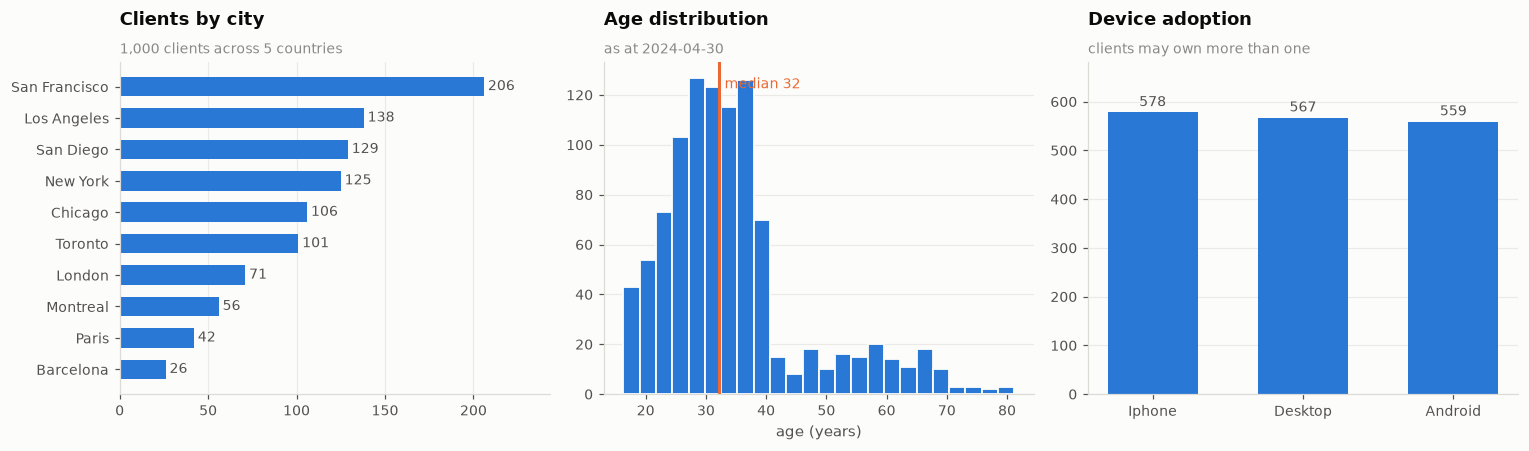

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# -- cities: magnitude -> one hue, ranked
city = clients["city"].value_counts().sort_values()
b = axes[0].barh(city.index, city.values, color=BLUE, height=0.62)
bar_labels(axes[0], b)
axes[0].set_xlim(0, city.max() * 1.18)
axes[0].grid(axis="y", visible=False)
titled(axes[0], "Clients by city", f"{len(clients):,} clients across {clients['country'].nunique()} countries")

# -- age distribution
axes[1].hist(clients["age"].dropna(), bins=24, color=BLUE, edgecolor=SURFACE, linewidth=1.2)
med = clients["age"].median()
axes[1].axvline(med, color=ORANGE, linewidth=2)
axes[1].text(med + 1, axes[1].get_ylim()[1] * 0.92, f"median {med:.0f}", color=ORANGE, fontsize=9)
axes[1].set_xlabel("age (years)")
axes[1].grid(axis="x", visible=False)
titled(axes[1], "Age distribution", "as at 2024-04-30")

# -- device adoption
b = axes[2].bar(dev.index, dev.values, color=BLUE, width=0.6)
bar_labels(axes[2], b, horizontal=False)
axes[2].set_ylim(0, dev.max() * 1.18)
axes[2].grid(axis="x", visible=False)
titled(axes[2], "Device adoption", "clients may own more than one")

fig.tight_layout()
plt.show()

## 3. Promotions

### 3.1 Which clients have what promotion?

In [5]:
promo = promotions.merge(clients[["id", "first_name", "last_name", "country", "city", "devices"]],
                         left_on="person_id", right_on="id", how="inner")
print(f"{len(promo)} promotions to {promo['person_id'].nunique()} distinct clients "
      f"({len(promotions) - len(promo)} rows belong to the synthetic entity)")

per_client = (promo.groupby("person_id")
              .agg(name=("first_name", "first"), last=("last_name", "first"),
                   country=("country", "first"), n=("promotion", "size"),
                   promos=("promotion", lambda s: ", ".join(sorted(s))),
                   yes=("responded", "sum"))
              .sort_values("n", ascending=False))
print(f"\nclients holding more than one promotion: {(per_client['n'] > 1).sum()}")
print("\ntop multi-promotion clients:")
print(per_client.head(8).to_string())

224 promotions to 194 distinct clients (12 rows belong to the synthetic entity)

clients holding more than one promotion: 26

top multi-promotion clients:
              name       last         country  n                          promos  yes
person_id                                                                            
31         Bradley     Butler          Canada  3  Krafty Cheddar, RedCow, RedCow    2
10           Keith    Donovan             USA  3     Coca-Splash, Flixnet, Oreoz    1
207           Mark   Friedman             USA  3     Colgatex, Flixnet, KittyKat    0
336        Katrina     Foster  United Kingdom  3    Coca-Splash, Dovee, KittyKat    1
7           Inaaya  Velasquez             USA  2            Coca-Splash, Flixnet    2
6             Dean      Lewis             USA  2            Coca-Splash, Flixnet    2
34           Livia       Howe          Canada  2              GatorBoost, RedCow    1
14          Harvey   Guerrero             USA  2              Coca-Spla

In [6]:
# client x promotion matrix -- who holds what
matrix = pd.crosstab(promo["person_id"], promo["promotion"])
print(f"matrix: {matrix.shape[0]} clients x {matrix.shape[1]} promotions")
print("\npromotion reach and response:")
summary = (promo.groupby("promotion")
           .agg(sent=("responded", "size"), yes=("responded", "sum"))
           .astype({"sent": int, "yes": int})
           .assign(response_rate=lambda d: d["yes"] / d["sent"])
           .sort_values("response_rate", ascending=False))
print(summary.to_string(formatters={"response_rate": "{:.1%}".format}))
overall = promo["responded"].mean()
print(f"\noverall response rate: {overall:.1%}")

matrix: 194 clients x 10 promotions

promotion reach and response:
                sent  yes response_rate
promotion                              
Popsi             24   14         58.3%
Oreoz             28   15         53.6%
Dovee             25   13         52.0%
Krafty Cheddar    14    7         50.0%
RedCow            22   11         50.0%
Coca-Splash       24   11         45.8%
GatorBoost        28   11         39.3%
Flixnet           21    7         33.3%
KittyKat          25    8         32.0%
Colgatex          13    3         23.1%

overall response rate: 44.6%


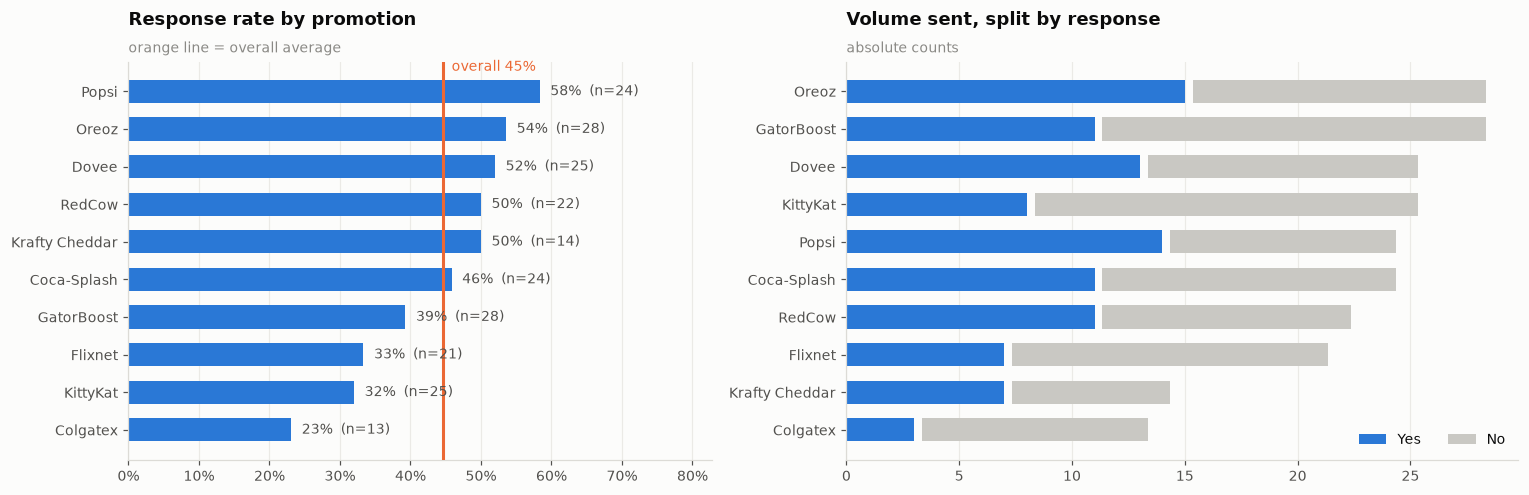

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.15]})

# -- response rate by promotion, ranked. One hue: this is magnitude, not identity.
s = summary.sort_values("response_rate")
b = axes[0].barh(s.index, s["response_rate"], color=BLUE, height=0.62)
axes[0].axvline(overall, color=ORANGE, linewidth=2, zorder=3)
axes[0].text(overall + .012, len(s) - 0.35, f"overall {overall:.0%}",
             color=ORANGE, fontsize=9, va="center")
for bar, (_, row) in zip(b, s.iterrows()):
    axes[0].text(row["response_rate"] + .015, bar.get_y() + bar.get_height() / 2,
                 f"{row['response_rate']:.0%}  (n={int(row['sent'])})",
                 va="center", fontsize=9, color=INK_2)
axes[0].set_xlim(0, s["response_rate"].max() * 1.42)
axes[0].xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[0].grid(axis="y", visible=False)
titled(axes[0], "Response rate by promotion", "orange line = overall average")

# -- volume split Yes/No -- two series, so a legend is present
sv = summary.sort_values("sent")
axes[1].barh(sv.index, sv["yes"], color=BLUE, height=0.62, label="Yes")
axes[1].barh(sv.index, sv["sent"] - sv["yes"], left=sv["yes"] + 0.35,
             color="#c9c8c3", height=0.62, label="No")     # 2px surface gap between fills
axes[1].grid(axis="y", visible=False)
axes[1].legend(loc="lower right", ncols=2)
titled(axes[1], "Volume sent, split by response", "absolute counts")

fig.tight_layout()
plt.show()

### 3.2 Turning "No" into "Yes"

Four angles, each pointing at a different lever: **channel**, **product affinity**,
**timing**, and **audience**.

In [8]:
# Lever 1 -- contact channel. The clean file records which key resolved each row.
by_channel = (promo.groupby("resolved_via")
              .agg(sent=("responded", "size"), yes=("responded", "sum"))
              .astype({"sent": int, "yes": int})
              .assign(rate=lambda d: d["yes"] / d["sent"]))
print("response rate by contact channel:")
print(by_channel.to_string(formatters={"rate": "{:.1%}".format}))

# Lever 2 -- product affinity: did the client actually buy the promoted item?
buyers = set(map(tuple, items.loc[items["is_clean"], ["person_id", "item"]]
                 .dropna().astype({"person_id": int}).drop_duplicates().to_numpy()))
promo["bought_item"] = [ (p, it) in buyers for p, it in
                         zip(promo["person_id"].astype("Int64"), promo["promotion"]) ]
affinity = (promo.groupby("bought_item")
            .agg(sent=("responded", "size"), yes=("responded", "sum"))
            .astype({"sent": int, "yes": int})
            .assign(rate=lambda d: d["yes"] / d["sent"]))
affinity.index = affinity.index.map({False: "never bought item", True: "has bought item"})
print("\nresponse rate by whether the client already buys the promoted item:")
print(affinity.to_string(formatters={"rate": "{:.1%}".format}))

response rate by contact channel:
              sent  yes  rate
resolved_via                 
email          155   70 45.2%
phone           69   30 43.5%

response rate by whether the client already buys the promoted item:
                   sent  yes  rate
bought_item                       
never bought item   203   88 43.3%
has bought item      21   12 57.1%


In [9]:
# Lever 3 -- timing
promo["month"] = promo["promotion_date"].dt.month
by_month = (promo.groupby("month")
            .agg(sent=("responded", "size"), yes=("responded", "sum"))
            .astype({"sent": int, "yes": int})
            .assign(rate=lambda d: d["yes"] / d["sent"]))

# Lever 4 -- audience: device reach and country
promo["n_devices"] = promo["devices"].map(len)
by_dev = (promo.groupby("n_devices")
          .agg(sent=("responded", "size"), yes=("responded", "sum"))
          .astype({"sent": int, "yes": int})
          .assign(rate=lambda d: d["yes"] / d["sent"]))
by_country = (promo.groupby("country")
              .agg(sent=("responded", "size"), yes=("responded", "sum"))
              .astype({"sent": int, "yes": int})
              .assign(rate=lambda d: d["yes"] / d["sent"])
              .sort_values("rate"))
print("by devices owned:")
print(by_dev.to_string(formatters={"rate": "{:.1%}".format}))
print("\nby country:")
print(by_country.to_string(formatters={"rate": "{:.1%}".format}))

by devices owned:
           sent  yes  rate
n_devices                 
1            86   39 45.3%
2            97   44 45.4%
3            41   17 41.5%

by country:
                sent  yes  rate
country                        
Spain             13    3 23.1%
United Kingdom    28    8 28.6%
France             6    2 33.3%
Canada            36   12 33.3%
USA              141   75 53.2%


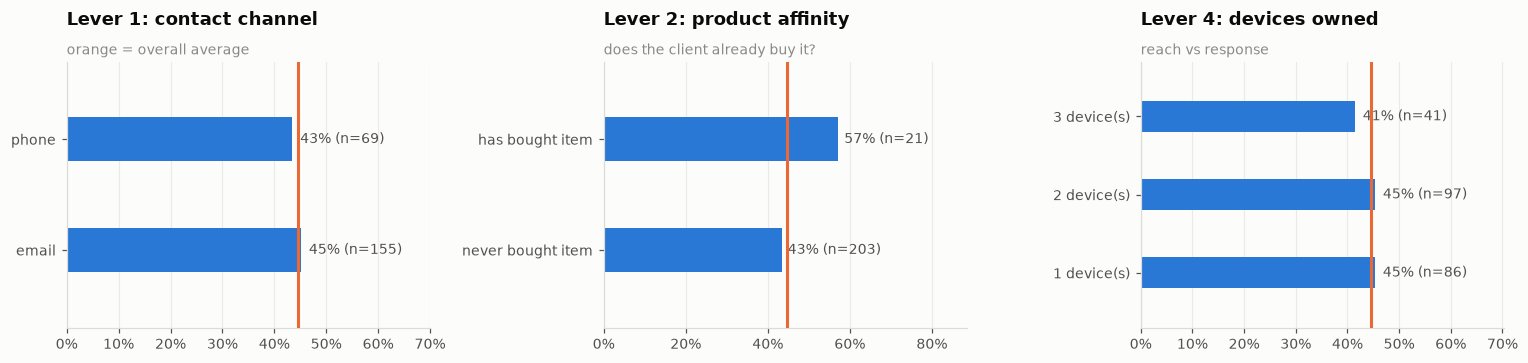

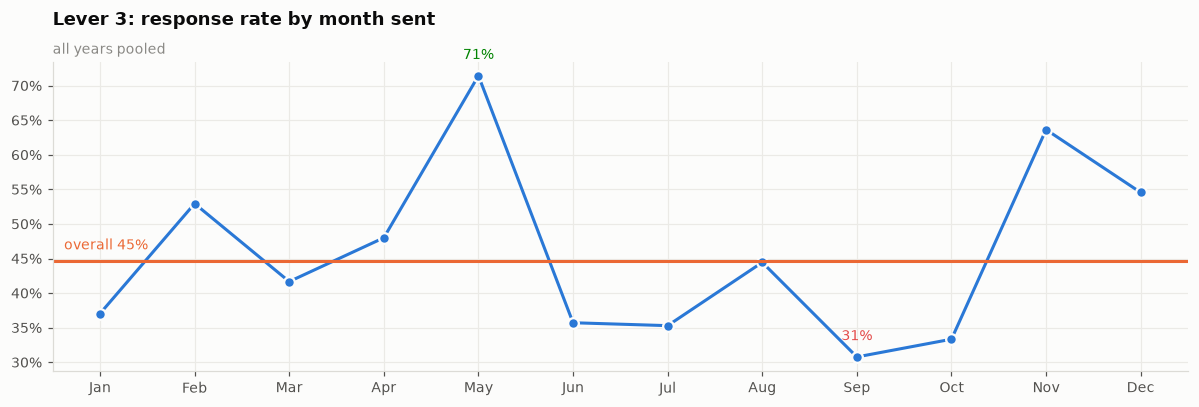

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))

def rate_bars(ax, frame, title, subtitle, labels=None):
    idx = labels if labels is not None else frame.index.astype(str)
    b = ax.barh(idx, frame["rate"], color=BLUE, height=0.4)
    for bar, (_, r) in zip(b, frame.iterrows()):
        ax.text(r["rate"] + .015, bar.get_y() + bar.get_height() / 2,
                f"{r['rate']:.0%} (n={int(r['sent'])})", va="center", fontsize=9, color=INK_2)
    ax.axvline(overall, color=ORANGE, linewidth=2, zorder=3)
    ax.set_xlim(0, max(frame["rate"].max(), overall) * 1.55)
    ax.set_ylim(-0.7, len(frame) - 0.3)
    ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.grid(axis="y", visible=False)
    titled(ax, title, subtitle)

rate_bars(axes[0], by_channel, "Lever 1: contact channel", "orange = overall average")
rate_bars(axes[1], affinity, "Lever 2: product affinity", "does the client already buy it?")
rate_bars(axes[2], by_dev, "Lever 4: devices owned",
          "reach vs response", labels=[f"{i} device(s)" for i in by_dev.index])

fig.tight_layout()
plt.show()

# Timing gets its own chart: change-over-time -> line, not bars.
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(by_month.index, by_month["rate"], color=BLUE, linewidth=2, marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.axhline(overall, color=ORANGE, linewidth=2)
ax.text(0.62, overall + .012, f"overall {overall:.0%}", color=ORANGE, fontsize=9, va="bottom")
best, worst = by_month["rate"].idxmax(), by_month["rate"].idxmin()
for m, c in ((best, GOOD), (worst, BAD)):
    ax.annotate(f"{by_month.loc[m, 'rate']:.0%}", (m, by_month.loc[m, "rate"]),
                textcoords="offset points", xytext=(0, 11), ha="center", fontsize=9, color=c)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_xlim(0.5, 12.5)
titled(ax, "Lever 3: response rate by month sent", "all years pooled")
fig.tight_layout()
plt.show()

In [11]:
# ---- the actionable output: a ranked retarget list ----------------------
# Clients who said No to a promotion for an item they demonstrably buy.
# The product is not the problem, so the offer or the channel is.
retarget = promo[(~promo["responded"]) & (promo["bought_item"])].copy()
spend = (items[items["is_clean"]].groupby(["person_id", "item"])["price"].sum()
         .rename("spend_on_item").reset_index())
retarget = retarget.merge(spend, left_on=["person_id", "promotion"],
                          right_on=["person_id", "item"], how="left")
retarget["client"] = retarget["first_name"] + " " + retarget["last_name"]
retarget = (retarget[["person_id", "client", "country", "promotion", "spend_on_item",
                      "resolved_via", "promotion_date"]]
            .sort_values("spend_on_item", ascending=False))

print(f"PRIORITY RETARGET LIST -- {len(retarget)} 'No' responses from proven buyers")
print(f"addressable spend already flowing to these items: ${retarget['spend_on_item'].sum():,.2f}\n")
print(retarget.head(15).to_string(index=False))
print("\nby promotion:")
print(retarget.groupby("promotion").agg(clients=("person_id", "nunique"),
                                        spend=("spend_on_item", "sum"))
      .sort_values("spend", ascending=False).to_string(formatters={"spend": money}))

PRIORITY RETARGET LIST -- 9 'No' responses from proven buyers
addressable spend already flowing to these items: $101.00

 person_id          client country  promotion  spend_on_item resolved_via promotion_date
        35     Linda Combs     USA    Flixnet           35.0        phone     2024-01-25
       218    Tony Shepard   Spain      Oreoz           18.0        phone     2024-01-05
       608    Rishi Barron  Canada      Oreoz           15.0        email     2022-09-20
        34      Livia Howe  Canada GatorBoost           15.0        phone     2023-03-09
       184   David Bridges     USA     RedCow            6.0        email     2023-09-10
       207   Mark Friedman     USA    Flixnet            5.0        email     2024-04-07
       362 Fletcher Moreno     USA    Flixnet            5.0        email     2022-09-19
       207   Mark Friedman     USA   Colgatex            1.0        phone     2024-03-27
       207   Mark Friedman     USA   KittyKat            1.0        phone     

## 4. Stores and items

In [12]:
sold = items[items["is_clean"]].copy()          # excludes the duplicate txn and bad-price rows
print(f"{len(sold)} clean line items / {len(items)} total")

by_item = (sold.groupby("item")
           .agg(units=("quantity", "sum"), revenue=("price", "sum"),
                orders=("transaction_id", "nunique"))
           .assign(avg_price=lambda d: d["revenue"] / d["units"])
           .sort_values("revenue", ascending=False))
print("\nBEST SELLER")
print(f"  by revenue : {by_item['revenue'].idxmax()}  (${by_item['revenue'].max():,.2f})")
print(f"  by units   : {by_item['units'].idxmax()}  ({by_item['units'].max():,.0f} units)")
print(f"  by orders  : {by_item['orders'].idxmax()}  ({by_item['orders'].max():,.0f} orders)")
print("\n" + by_item.to_string(formatters={"revenue": money, "avg_price": "${:,.2f}".format}))

353 clean line items / 360 total

BEST SELLER
  by revenue : Flixnet  ($603.00)
  by units   : Dovee  (110 units)
  by orders  : Dovee  (63 orders)

                units revenue  orders avg_price
item                                           
Flixnet          61.0    $603      44     $9.89
RedCow           95.0    $353      43     $3.72
Popsi            81.0    $273      42     $3.37
Krafty Cheddar   51.0    $245      28     $4.80
Dovee           110.0    $206      63     $1.87
Colgatex         67.0    $197      44     $2.94
KittyKat         62.0    $151      32     $2.44
Oreoz            46.0    $142      28     $3.09
GatorBoost       40.0    $125      20     $3.12
Coca-Splash      29.0     $84       6     $2.90


In [13]:
by_store = (sold.groupby("store")
            .agg(revenue=("price", "sum"), orders=("transaction_id", "nunique"),
                 units=("quantity", "sum"), customers=("person_id", "nunique"))
            .assign(aov=lambda d: d["revenue"] / d["orders"],
                    basket=lambda d: d["units"] / d["orders"])
            .sort_values("revenue", ascending=False))
print("STORE PERFORMANCE  (revenue -- we have price but no cost, so this is not margin)")
print(by_store.to_string(formatters={"revenue": money, "aov": "${:,.2f}".format,
                                     "basket": "{:.1f}".format}))
print(f"\ntop store by revenue : {by_store['revenue'].idxmax()}")
print(f"top store by AOV     : {by_store['aov'].idxmax()} (${by_store['aov'].max():,.2f})")

STORE PERFORMANCE  (revenue -- we have price but no cost, so this is not margin)
                      revenue  orders  units  customers    aov basket
store                                                                
Trader Tales             $606      53  157.0         41 $11.43    3.0
Urban Outfitters Loft    $588      48  173.0         48 $12.25    3.6
SparkMart                $430      20   95.0         20 $21.50    4.8
PetPals Mart             $408      38  127.0         36 $10.74    3.3
BestChoice Buy           $313      22   82.0         22 $14.23    3.7
Targeted Treasures        $34       3    8.0          3 $11.33    2.7

top store by revenue : Trader Tales
top store by AOV     : SparkMart ($21.50)


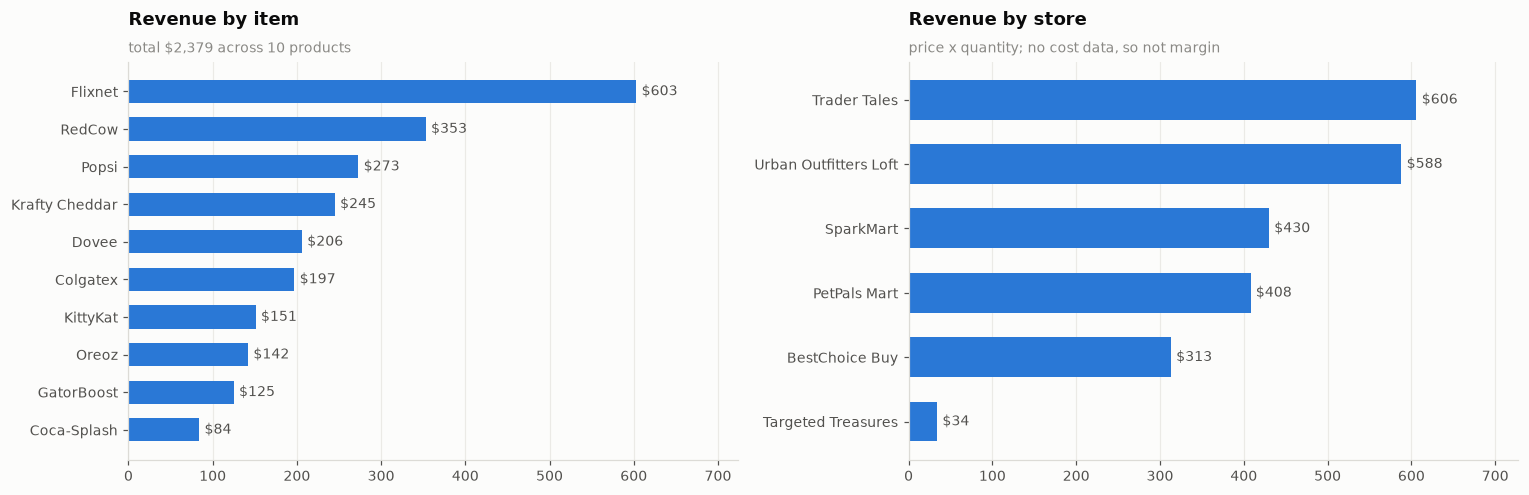

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

r = by_item.sort_values("revenue")
b = axes[0].barh(r.index, r["revenue"], color=BLUE, height=0.62)
bar_labels(axes[0], b, fmt="${:,.0f}")
axes[0].set_xlim(0, r["revenue"].max() * 1.2)
axes[0].grid(axis="y", visible=False)
titled(axes[0], "Revenue by item", f"total ${sold['price'].sum():,.0f} across {len(by_item)} products")

s = by_store.sort_values("revenue")
b = axes[1].barh(s.index, s["revenue"], color=BLUE, height=0.62)
bar_labels(axes[1], b, fmt="${:,.0f}")
axes[1].set_xlim(0, s["revenue"].max() * 1.2)
axes[1].grid(axis="y", visible=False)
titled(axes[1], "Revenue by store", "price x quantity; no cost data, so not margin")

fig.tight_layout()
plt.show()

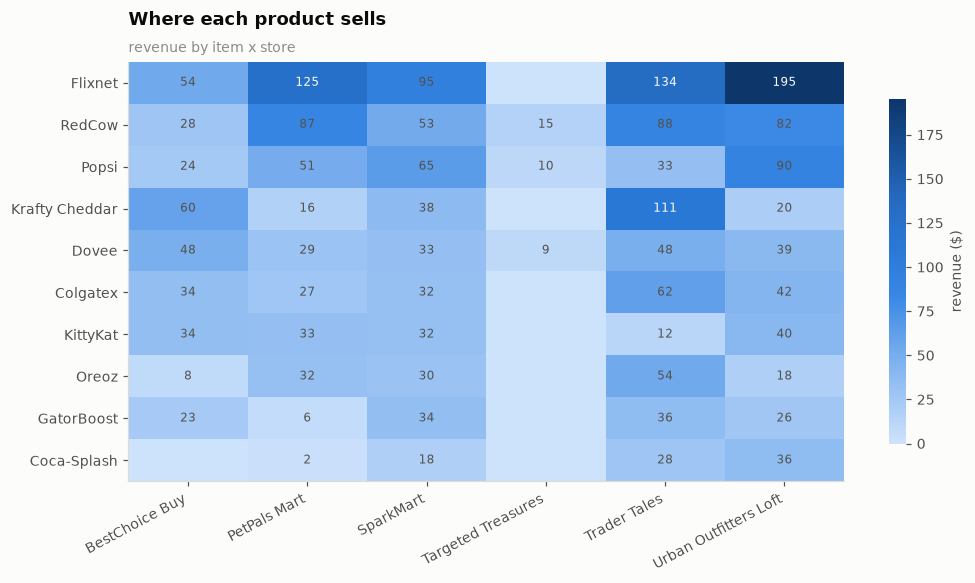

In [15]:
# item x store concentration -- continuous magnitude, so a single-hue sequential ramp
pivot = (sold.pivot_table(index="item", columns="store", values="price",
                          aggfunc="sum", fill_value=0)
         .loc[by_item.index])

fig, ax = plt.subplots(figsize=(9.5, 5.4))
im = ax.imshow(pivot.values, cmap=BLUE_CMAP, aspect="auto")
ax.set_xticks(range(pivot.shape[1]), pivot.columns, rotation=28, ha="right")
ax.set_yticks(range(pivot.shape[0]), pivot.index)
ax.grid(False)
mx = pivot.values.max()
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if v > 0:                                   # direct labels: the table view, in place
            ax.text(j, i, f"{v:,.0f}", ha="center", va="center", fontsize=8,
                    color=SURFACE if v > mx * 0.55 else INK_2)
cb = fig.colorbar(im, ax=ax, shrink=0.82)
cb.set_label("revenue ($)", color=INK_2, fontsize=9)
cb.outline.set_visible(False)
titled(ax, "Where each product sells", "revenue by item x store")
fig.tight_layout()
plt.show()

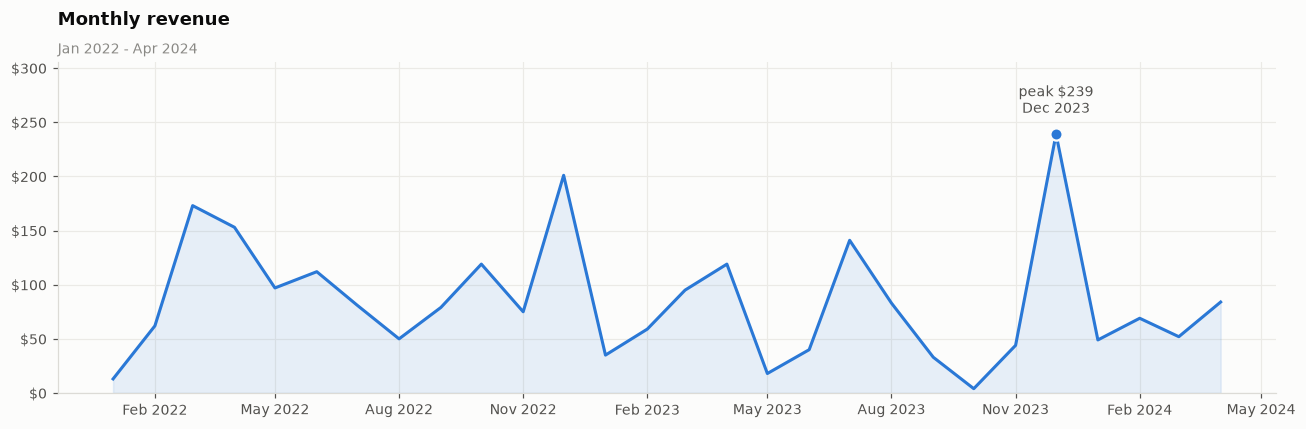

In [16]:
# revenue over time -- change-over-time -> line
monthly = (sold.set_index("date").resample("MS")
           .agg(revenue=("price", "sum"), orders=("transaction_id", "nunique")))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly["revenue"], color=BLUE, linewidth=2)
ax.fill_between(monthly.index, monthly["revenue"], color=BLUE, alpha=0.10)
peak = monthly["revenue"].idxmax()
ax.scatter([peak], [monthly.loc[peak, "revenue"]], s=64, color=BLUE,
           edgecolor=SURFACE, linewidth=1.5, zorder=3)
ax.annotate(f"peak ${monthly.loc[peak, 'revenue']:,.0f}\n{peak:%b %Y}",
            (peak, monthly.loc[peak, "revenue"]), textcoords="offset points",
            xytext=(0, 14), ha="center", fontsize=9, color=INK_2)
ax.yaxis.set_major_formatter(FuncFormatter(money))
ax.xaxis.set_major_locator(MonthLocator(interval=3))
ax.xaxis.set_major_formatter(DateFormatter("%b %Y"))
ax.set_ylim(0, monthly["revenue"].max() * 1.28)
titled(ax, "Monthly revenue", f"{monthly.index.min():%b %Y} - {monthly.index.max():%b %Y}")
fig.tight_layout()
plt.show()

## 5. Transfers

### 5.1 What the transfer file gives us

In [17]:
tf = transfers[transfers["is_clean"]].copy()
print(f"{len(tf)} clean transfers / {len(transfers)} total "
      f"({transfers['is_null_row'].sum()} null, "
      f"{(~transfers['is_clean'] & ~transfers['is_null_row']).sum()} flagged)")
print(f"value moved: ${tf['amount'].sum():,.2f}   median ${tf['amount'].median():.2f}")

sent = tf.groupby("sender_id")["amount"].agg(["sum", "count"]).add_prefix("sent_")
recv = tf.groupby("recipient_id")["amount"].agg(["sum", "count"]).add_prefix("recv_")
flow = (sent.join(recv, how="outer").fillna(0)
        .assign(net=lambda d: d["recv_sum"] - d["sent_sum"],
                degree=lambda d: d["sent_count"] + d["recv_count"]))
flow.index.name = "person_id"
flow = flow.join(clients.set_index("id")[["first_name", "last_name", "country"]])
flow["client"] = flow["first_name"] + " " + flow["last_name"]

print(f"\nclients touching the transfer network: {len(flow)} of {len(clients)} "
      f"({len(flow)/len(clients):.0%})")
print("\nTOP NET RECEIVERS")
print(flow.nlargest(5, "net")[["client", "country", "recv_sum", "sent_sum", "net"]]
      .to_string(formatters={c: money for c in ("recv_sum", "sent_sum", "net")}))
print("\nTOP NET SENDERS")
print(flow.nsmallest(5, "net")[["client", "country", "recv_sum", "sent_sum", "net"]]
      .to_string(formatters={c: money for c in ("recv_sum", "sent_sum", "net")}))

533 clean transfers / 614 total (15 null, 66 flagged)
value moved: $19,120.39   median $29.80

clients touching the transfer network: 570 of 1000 (57%)

TOP NET RECEIVERS
                   client country recv_sum sent_sum  net
person_id                                               
947          Isra Burgess     USA     $358       $0 $358
913        Ricardo Odling     USA     $231      $13 $218
973          Jean Winters     USA     $258      $66 $192
963          Billy Norton     USA     $224      $38 $185
813         Arthur Hebert     USA     $179       $0 $179

TOP NET SENDERS
                    client         country recv_sum sent_sum   net
person_id                                                         
289         Adele Cantrell             USA       $0     $244 $-244
979        Myrtle Bradford             USA      $57     $292 $-235
878          Mateo Francis             USA       $0     $225 $-225
938          Alisha Hoover             USA       $0     $194 $-194
59         

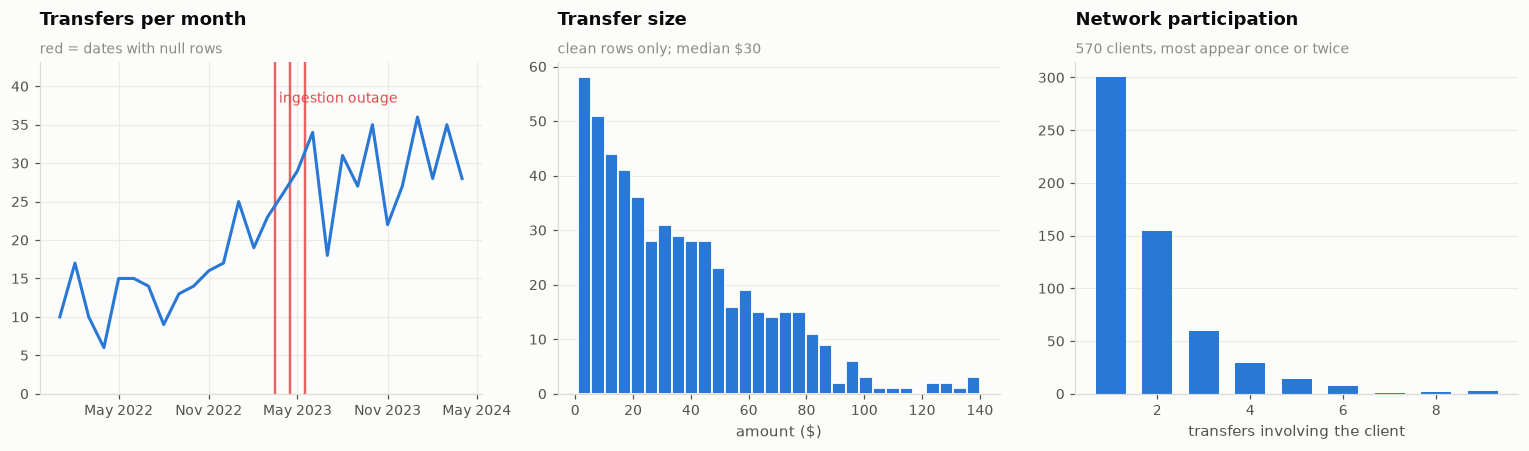

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# volume over time, with the ingestion outage marked
mtf = transfers[~transfers["is_null_row"]].set_index("date").resample("MS").size()
axes[0].plot(mtf.index, mtf.values, color=BLUE, linewidth=2)
for d in outages["date"]:
    axes[0].axvline(d, color=BAD, linewidth=1.6, alpha=0.85, zorder=1)
axes[0].text(outages["date"].iloc[0], mtf.max() * 1.04, " ingestion outage",
             color=BAD, fontsize=9, va="bottom")
axes[0].set_ylim(0, mtf.max() * 1.2)
axes[0].xaxis.set_major_locator(MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(DateFormatter("%b %Y"))
titled(axes[0], "Transfers per month", "red = dates with null rows")

# amount distribution (clean only)
axes[1].hist(tf["amount"], bins=30, color=BLUE, edgecolor=SURFACE, linewidth=1.2)
axes[1].set_xlabel("amount ($)")
axes[1].grid(axis="x", visible=False)
titled(axes[1], "Transfer size", f"clean rows only; median ${tf['amount'].median():.0f}")

# how connected is the network?
deg = flow["degree"].value_counts().sort_index()
axes[2].bar(deg.index, deg.values, color=BLUE, width=0.65)
axes[2].set_xlabel("transfers involving the client")
axes[2].grid(axis="x", visible=False)
titled(axes[2], "Network participation", f"{len(flow)} clients, most appear once or twice")

fig.tight_layout()
plt.show()

### 5.2 Use case: transfers as a spending signal

In [19]:
spend_by_client = sold.groupby("person_id")["price"].sum().rename("spend")
joined = (flow[["client", "country", "recv_sum", "sent_sum", "net", "degree"]]
          .join(spend_by_client, how="left"))
joined["spend"] = joined["spend"].fillna(0)
joined["buys"] = joined["spend"] > 0

print("do clients who receive money spend more in stores?")
print(joined.groupby("buys")[["recv_sum", "sent_sum", "degree"]].mean()
      .to_string(formatters={"recv_sum": money, "sent_sum": money, "degree": "{:.2f}".format}))
active = joined[joined["spend"] > 0]
if len(active) > 2:
    print(f"\ncorrelation between money received and store spend "
          f"(n={len(active)}): r = {active['recv_sum'].corr(active['spend']):.3f}")
print(f"\ntransfer-active clients who never transact in a store: "
      f"{(joined['spend'] == 0).sum()} of {len(joined)} -- a cross-sell audience")

do clients who receive money spend more in stores?
      recv_sum sent_sum degree
buys                          
False      $34      $33   1.89
True       $30      $38   1.80

correlation between money received and store spend (n=99): r = -0.070

transfer-active clients who never transact in a store: 471 of 570 -- a cross-sell audience


### 5.3 The flagged rows: a fraud-detection surface

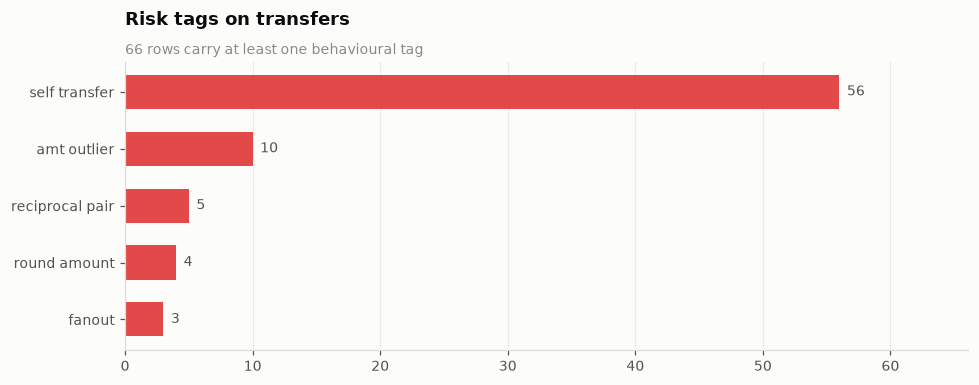

highest-risk rows -- multiple independent tags:
 sender_id  recipient_id   amount       date                           flags
       123           456  5000.00 2023-08-01 amt_outlier|round_amount|fanout
       123           789  5000.00 2023-08-01 amt_outlier|round_amount|fanout
       123           321  5000.00 2023-08-01 amt_outlier|round_amount|fanout
       654           123 15000.00 2023-09-30        amt_outlier|round_amount
       777           888   999.99 2023-06-15     amt_outlier|reciprocal_pair
       888           777   999.99 2023-06-16     amt_outlier|reciprocal_pair
       777           888   999.99 2023-06-17     amt_outlier|reciprocal_pair
       888           777   999.99 2023-06-18     amt_outlier|reciprocal_pair
       777           888   999.99 2023-06-19     amt_outlier|reciprocal_pair


In [20]:
flagged = transfers[~transfers["is_clean"] & ~transfers["is_null_row"]]
FLAGCOLS = ["is_self_transfer", "is_amt_outlier", "is_round_amount",
            "is_reciprocal_pair", "is_fanout"]
counts = transfers[FLAGCOLS].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 3.6))
b = ax.barh([c[3:].replace("_", " ") for c in counts.index][::-1], counts.values[::-1],
            color=BAD, height=0.6)
bar_labels(ax, b)
ax.set_xlim(0, counts.max() * 1.18)
ax.grid(axis="y", visible=False)
titled(ax, "Risk tags on transfers", f"{len(flagged)} rows carry at least one behavioural tag")
fig.tight_layout()
plt.show()

print("highest-risk rows -- multiple independent tags:")
print(flagged.assign(n_flags=flagged[FLAGCOLS].sum(axis=1))
      .nlargest(9, ["n_flags", "amount"])
      [["sender_id", "recipient_id", "amount", "date", "flags"]].to_string(index=False))

## 6. Cross-dataset view

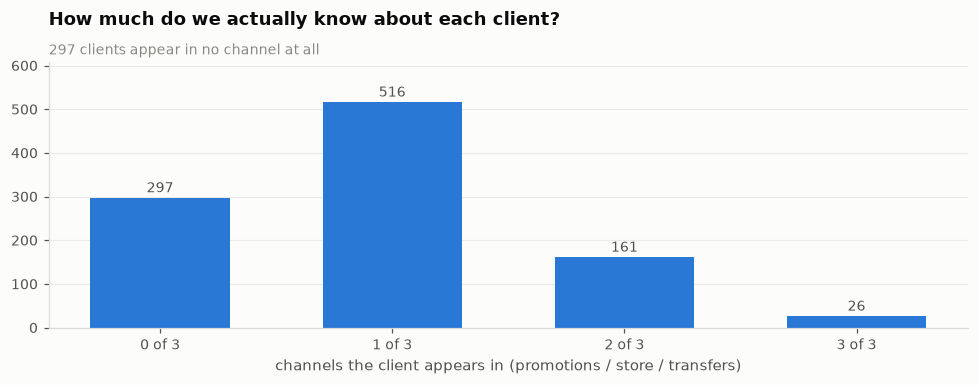

most engaged clients (all three channels):
    first_name  last_name         country  promos  orders spend  degree
id                                                                     
69     Saoirse     Keller             USA     1.0     2.0   $68     1.0
828       Nora  Donaldson             USA     1.0     1.0   $68     2.0
42       Tomas   Griffith  United Kingdom     2.0     2.0   $65     1.0
258   Felicity       Tran             USA     2.0     3.0   $49     3.0
197      Tiago       Dunn             USA     1.0     1.0   $37     1.0
202      Kabir    Stewart             USA     1.0     2.0   $37     1.0
980      Kacie     Lester          Canada     1.0     1.0   $33     2.0
10       Keith    Donovan             USA     3.0     1.0   $28     1.0


In [21]:
profile = (clients.set_index("id")[["first_name", "last_name", "country", "age"]]
           .join(promotions.groupby("person_id").agg(promos=("promotion", "size"),
                                                     promo_yes=("responded", "sum")))
           .join(sold.groupby("person_id").agg(orders=("transaction_id", "nunique"),
                                               spend=("price", "sum")))
           .join(flow[["degree", "net"]])
           .fillna({"promos": 0, "promo_yes": 0, "orders": 0, "spend": 0, "degree": 0, "net": 0}))
profile["channels"] = ((profile["promos"] > 0).astype(int) + (profile["orders"] > 0).astype(int)
                       + (profile["degree"] > 0).astype(int))

reach = profile["channels"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 3.6))
b = ax.bar([f"{i} of 3" for i in reach.index], reach.values, color=BLUE, width=0.6)
bar_labels(ax, b, horizontal=False)
ax.set_ylim(0, reach.max() * 1.18)
ax.set_xlabel("channels the client appears in (promotions / store / transfers)")
ax.grid(axis="x", visible=False)
titled(ax, "How much do we actually know about each client?",
       f"{(profile['channels'] == 0).sum()} clients appear in no channel at all")
fig.tight_layout()
plt.show()

print("most engaged clients (all three channels):")
print(profile[profile["channels"] == 3].nlargest(8, "spend")
      [["first_name", "last_name", "country", "promos", "orders", "spend", "degree"]]
      .to_string(formatters={"spend": money}))

## 7. Statistical tests

The EDA surfaced four candidate effects. This section tests which survive.

| Test | Question |
|---|---|
| 7.1 Chi-square / Fisher, 2x2 | Does product affinity drive response? |
| 7.2 Logistic regression | Which lever matters, holding the others constant? |
| 7.3 Chi-square, promotion x response | Is the 58%-to-23% spread real? |
| 7.4 Chi-square, month x response | Is the seasonality real? |
| 7.5 Power analysis | Which comparisons is this sample even able to detect? |

Requires `scipy` and `statsmodels`:

```
pip install scipy statsmodels
```

In [22]:
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize, proportion_confint

ALPHA = 0.05
results = []          # (test, question, statistic, p, verdict)

def verdict(p, alpha=ALPHA):
    return "SIGNIFICANT" if p < alpha else "not significant"

def record(test, question, stat, p):
    results.append((test, question, stat, p, verdict(p)))
    print(f"{test}: {stat}, p = {p:.4f} -> {verdict(p)}")

### 7.1 Product affinity — does already buying the item predict response?

In [23]:
table = pd.crosstab(promo["bought_item"], promo["responded"])
table.index = table.index.map({False: "never bought", True: "has bought"})
table.columns = table.columns.map({False: "No", True: "Yes"})
print(table.to_string(), "\n")

rate_buy = table.loc["has bought", "Yes"] / table.loc["has bought"].sum()
rate_non = table.loc["never bought", "Yes"] / table.loc["never bought"].sum()
for lab, k, n in [("has bought", table.loc["has bought", "Yes"], table.loc["has bought"].sum()),
                  ("never bought", table.loc["never bought", "Yes"], table.loc["never bought"].sum())]:
    lo, hi = proportion_confint(k, n, method="wilson")
    print(f"  {lab:<13} {k:>3}/{n:<3}  {k/n:.1%}   95% CI [{lo:.1%}, {hi:.1%}]")

chi2, p_chi, dof, expected = stats.chi2_contingency(table)
odds, p_fisher = stats.fisher_exact(table.values)
print(f"\nsmallest expected cell = {expected.min():.1f}"
      f"  ({'chi-square valid' if expected.min() >= 5 else 'use Fisher -- expected cell < 5'})")
print(f"absolute lift: {rate_buy - rate_non:+.1%}")
record("7.1 affinity (chi-square)", "does affinity drive response?", f"chi2 = {chi2:.2f}", p_chi)
record("7.1 affinity (Fisher)", "does affinity drive response?", f"odds ratio = {odds:.2f}", p_fisher)

responded      No  Yes
bought_item           
never bought  115   88
has bought      9   12 

  has bought     12/21   57.1%   95% CI [36.5%, 75.5%]
  never bought   88/203  43.3%   95% CI [36.7%, 50.2%]

smallest expected cell = 9.4  (chi-square valid)
absolute lift: +13.8%
7.1 affinity (chi-square): chi2 = 0.96, p = 0.3272 -> not significant
7.1 affinity (Fisher): odds ratio = 1.74, p = 0.2546 -> not significant


### 7.2 Logistic regression
It classifies whether a client says Yes or No to a promotion.

Target: responded (1 = Yes, 0 = No), one row per promotion sent
Predictors: whether they already buy that item, how many devices they own, their country...Essentially which client attribute actually drives a Yes, holding the others constant?

In [24]:
model_df = promo.assign(
    responded_i=promo["responded"].astype(int),
    bought=promo["bought_item"].astype(int),
    n_dev=promo["n_devices"],
    month_num=promo["promotion_date"].dt.month,
).dropna(subset=["responded_i", "bought", "n_dev", "country"])

# Parsimonious by design: ~236 rows cannot support promotion and country dummies
# plus interactions without overfitting. Country is collapsed to the three
# levels with enough support.
top_countries = model_df["country"].value_counts().loc[lambda s: s >= 15].index
model_df["country_g"] = model_df["country"].where(model_df["country"].isin(top_countries), "Other")

fit = smf.logit("responded_i ~ bought + n_dev + C(country_g)", data=model_df).fit(disp=False)
print(fit.summary2().tables[1].to_string(), "\n")

odds_ratios = pd.DataFrame({
    "odds_ratio": np.exp(fit.params),
    "ci_low": np.exp(fit.conf_int()[0]),
    "ci_high": np.exp(fit.conf_int()[1]),
    "p": fit.pvalues,
}).drop("Intercept")
print(odds_ratios.to_string(float_format=lambda v: f"{v:.3f}"))
print(f"\nn = {int(fit.nobs)}, pseudo R-squared = {fit.prsquared:.3f}, "
      f"LLR p = {fit.llr_pvalue:.4f}")
record("7.2 logistic (bought)", "affinity, controlling for country and devices",
       f"OR = {odds_ratios.loc['bought', 'odds_ratio']:.2f}", odds_ratios.loc["bought", "p"])

                                   Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
Intercept                      -0.673513  0.483654 -1.392551  0.163756 -1.621457  0.274431
C(country_g)[T.Other]          -0.292966  0.633513 -0.462447  0.643760 -1.534628  0.948696
C(country_g)[T.USA]             0.837807  0.393988  2.126480  0.033463  0.065605  1.610008
C(country_g)[T.United Kingdom] -0.194595  0.550455 -0.353516  0.723702 -1.273467  0.884278
bought                          0.526843  0.475017  1.109104  0.267385 -0.404173  1.457858
n_dev                          -0.048585  0.190701 -0.254770  0.798901 -0.422352  0.325183 

                                odds_ratio  ci_low  ci_high     p
C(country_g)[T.Other]                0.746   0.216    2.582 0.644
C(country_g)[T.USA]                  2.311   1.068    5.003 0.033
C(country_g)[T.United Kingdom]       0.823   0.280    2.421 0.724
bought                               1.694   0.668    4.297 0.267
n_dev                          

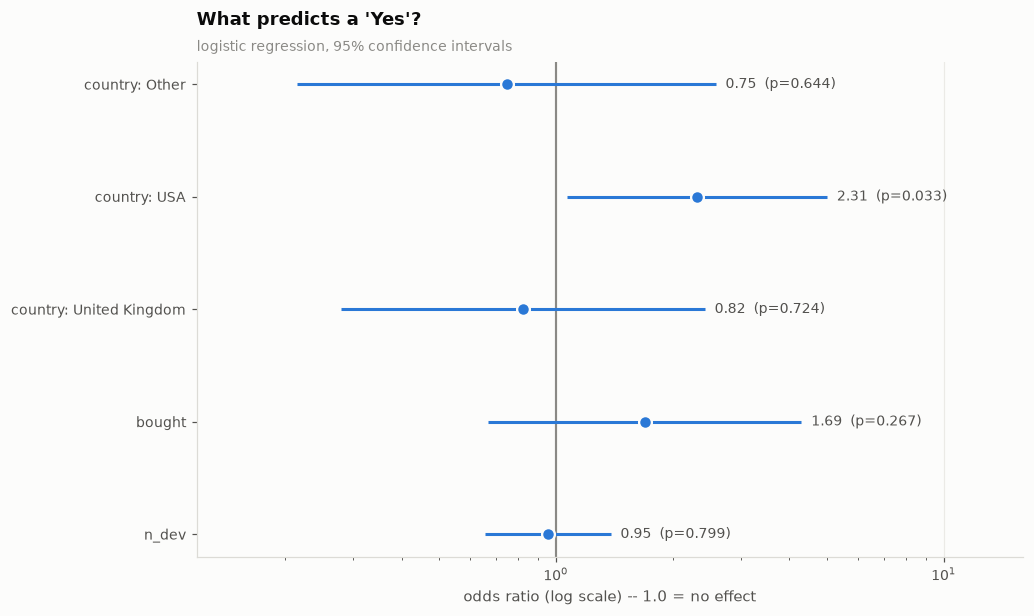

In [25]:
# Odds ratios with 95% CI. One series -> no legend; the null line carries the reading.
o = odds_ratios.iloc[::-1]
y = np.arange(len(o))
fig, ax = plt.subplots(figsize=(9.5, 0.7 * len(o) + 2.2))
ax.axvline(1, color=INK_3, linewidth=1.4, zorder=1)
ax.hlines(y, o["ci_low"], o["ci_high"], color=BLUE, linewidth=2, zorder=2)
ax.scatter(o["odds_ratio"], y, s=70, color=BLUE, edgecolor=SURFACE, linewidth=1.5, zorder=3)
for i, (name, r) in enumerate(o.iterrows()):
    ax.text(r["ci_high"] * 1.06, i, f"{r['odds_ratio']:.2f}  (p={r['p']:.3f})",
            va="center", fontsize=9, color=INK_2)
ax.set_yticks(y, [n.replace("C(country_g)[T.", "country: ").replace("]", "") for n in o.index])
ax.set_xscale("log")
ax.set_xlim(o["ci_low"].min() * 0.55, o["ci_high"].max() * 3.2)
ax.set_xlabel("odds ratio (log scale) -- 1.0 = no effect")
ax.grid(axis="y", visible=False)
titled(ax, "What predicts a 'Yes'?", "logistic regression, 95% confidence intervals")
fig.tight_layout()
plt.show()

### 7.3 / 7.4 Is the promotion spread or the seasonality real?

In [26]:
ct_promo = pd.crosstab(promo["promotion"], promo["responded"])
chi2_p, p_promo, _, exp_p = stats.chi2_contingency(ct_promo)
print(f"promotion x response: {ct_promo.shape[0]} promotions, "
      f"smallest expected cell {exp_p.min():.1f}")
record("7.3 promotion spread", "is the 58%-to-23% spread real?", f"chi2 = {chi2_p:.2f}", p_promo)

ct_month = pd.crosstab(promo["promotion_date"].dt.month, promo["responded"])
chi2_m, p_month, _, exp_m = stats.chi2_contingency(ct_month)
print(f"\nmonth x response: smallest expected cell {exp_m.min():.1f}")
record("7.4 seasonality", "is the May-vs-September swing real?", f"chi2 = {chi2_m:.2f}", p_month)

print("\nBoth have expected cells below 5, so treat the p-values as approximate --")
print("the conclusion (no detectable effect) is unchanged either way.")

promotion x response: 10 promotions, smallest expected cell 5.8
7.3 promotion spread: chi2 = 9.18, p = 0.4210 -> not significant

month x response: smallest expected cell 4.0
7.4 seasonality: chi2 = 11.39, p = 0.4110 -> not significant

Both have expected cells below 5, so treat the p-values as approximate --
the conclusion (no detectable effect) is unchanged either way.


### 7.5 Power — what can this sample actually detect?

In [27]:
comparisons = [
    ("affinity",            rate_non, rate_buy,
     table.loc["never bought"].sum(), table.loc["has bought"].sum()),
    ("channel (email/phone)", by_channel.loc["phone", "rate"], by_channel.loc["email", "rate"],
     int(by_channel.loc["phone", "sent"]), int(by_channel.loc["email", "sent"])),
    ("Popsi vs Colgatex",  summary["response_rate"].min(), summary["response_rate"].max(),
     int(summary["sent"].min()), int(summary["sent"].max())),
]
rows = []
for name, p0, p1, n0, n1 in comparisons:
    need = zt_ind_solve_power(effect_size=proportion_effectsize(p1, p0), alpha=ALPHA, power=0.80)
    rows.append({"comparison": name, "rate_a": p0, "rate_b": p1,
                 "n_per_group_needed": round(need), "smallest_group_have": min(n0, n1),
                 "powered": min(n0, n1) >= need})
power = pd.DataFrame(rows)
print(power.to_string(index=False, formatters={"rate_a": "{:.1%}".format, "rate_b": "{:.1%}".format}))
print("\nOnly the powered comparison should drive a decision. The channel gap needs")
print("orders of magnitude more data -- and channel was forced by missing contact")
print("fields, not assigned, so it is confounded as well as underpowered.")

           comparison rate_a rate_b  n_per_group_needed  smallest_group_have  powered
             affinity  43.3%  57.1%                 205                   21    False
channel (email/phone)  43.5%  45.2%               13674                   69    False
    Popsi vs Colgatex  23.1%  58.3%                  29                   13    False

Only the powered comparison should drive a decision. The channel gap needs
orders of magnitude more data -- and channel was forced by missing contact
fields, not assigned, so it is confounded as well as underpowered.


In [28]:
summary_tests = pd.DataFrame(results, columns=["test", "question", "statistic", "p_value", "verdict"])
print(summary_tests.to_string(index=False, formatters={"p_value": "{:.4f}".format}))
print("\nCAVEAT: this dataset is synthetic with deliberately planted patterns.")
print("A significant result may be measuring the generator, not customer behaviour.")
print("Treat these as methodology validation and confirm on production data.")

                     test                                      question         statistic p_value         verdict
7.1 affinity (chi-square)                 does affinity drive response?       chi2 = 0.96  0.3272 not significant
    7.1 affinity (Fisher)                 does affinity drive response? odds ratio = 1.74  0.2546 not significant
    7.2 logistic (bought) affinity, controlling for country and devices         OR = 1.69  0.2674 not significant
     7.3 promotion spread                is the 58%-to-23% spread real?       chi2 = 9.18  0.4210 not significant
          7.4 seasonality           is the May-vs-September swing real?      chi2 = 11.39  0.4110 not significant

CAVEAT: this dataset is synthetic with deliberately planted patterns.
A significant result may be measuring the generator, not customer behaviour.
Treat these as methodology validation and confirm on production data.


## 8. Headline findings

In [29]:
lines = [
 ("CLIENTS",
  f"{len(clients):,} clients, median age {clients['age'].median():.0f}, "
  f"{clients['country'].nunique()} countries; "
  f"{clients['country'].value_counts().idxmax()} is {clients['country'].value_counts(normalize=True).max():.0%} of the base."),
 ("PROMOTIONS",
  f"Overall response {overall:.0%}. Best: {summary['response_rate'].idxmax()} "
  f"({summary['response_rate'].max():.0%}); worst: {summary['response_rate'].idxmin()} "
  f"({summary['response_rate'].min():.0%})."),
 ("TURNING NO -> YES",
  f"{len(retarget)} 'No' responses came from clients who already buy the promoted item "
  f"(${retarget['spend_on_item'].sum():,.0f} of existing spend). Offer/channel problem, not product."),
 ("CHANNEL",
  "Email vs phone response: "
  + ", ".join(f"{k} {v:.0%}" for k, v in by_channel["rate"].items())
  + " -- promotions.csv is missing one contact field on 154 of 236 rows, so channel choice is forced, not chosen."),
 ("BEST SELLER",
  f"{by_item['revenue'].idxmax()} leads revenue (${by_item['revenue'].max():,.0f}); "
  f"{by_item['units'].idxmax()} leads units ({by_item['units'].max():,.0f})."),
 ("STORES",
  f"{by_store['revenue'].idxmax()} tops revenue (${by_store['revenue'].max():,.0f}); "
  f"{by_store['aov'].idxmax()} has the best basket value (${by_store['aov'].max():,.2f}). "
  "No cost data, so revenue is a proxy for profit."),
 ("TRANSFERS",
  f"{len(tf)} clean transfers moving ${tf['amount'].sum():,.0f}; "
  f"{len(flow)} clients participate ({len(flow)/len(clients):.0%}). "
  f"{(joined['spend'] == 0).sum()} of them never buy in a store -- a cross-sell audience."),
 ("RISK",
  f"{len(flagged)} transfers carry behavioural tags (wash-trade pair, same-day fan-out, "
  f"far-out amounts). Retained, not deleted -- this is the fraud training signal."),
 ("DATA GAPS",
  f"{transfers['is_null_row'].sum()} null transfer rows on three consecutive month-16ths "
  f"(ingestion outage), 4 orphan transaction phones, and "
  f"{(profile['channels'] == 0).sum()} clients with no activity in any channel."),
]
for head, body in lines:
    print(f"\n{head}\n  " + body)


CLIENTS
  1,000 clients, median age 32, 5 countries; USA is 70% of the base.

PROMOTIONS
  Overall response 45%. Best: Popsi (58%); worst: Colgatex (23%).

TURNING NO -> YES
  9 'No' responses came from clients who already buy the promoted item ($101 of existing spend). Offer/channel problem, not product.

CHANNEL
  Email vs phone response: email 45%, phone 43% -- promotions.csv is missing one contact field on 154 of 236 rows, so channel choice is forced, not chosen.

BEST SELLER
  Flixnet leads revenue ($603); Dovee leads units (110).

STORES
  Trader Tales tops revenue ($606); SparkMart has the best basket value ($21.50). No cost data, so revenue is a proxy for profit.

TRANSFERS
  533 clean transfers moving $19,120; 570 clients participate (57%). 471 of them never buy in a store -- a cross-sell audience.

RISK
  66 transfers carry behavioural tags (wash-trade pair, same-day fan-out, far-out amounts). Retained, not deleted -- this is the fraud training signal.

DATA GAPS
  15 null t

## Get basic counts on the clean data for a sanity check. Not formal statistical analysis. 

In [30]:
sold = items[items["is_clean"]]
tf   = transfers[transfers["is_clean"]]
pd.set_option("display.width", 140)

# ---------------------------------------------------------------- row level
print("=" * 78)
print("ROW-LEVEL DESCRIPTIVES")
print("=" * 78)

txn = (sold.groupby("transaction_id")
       .agg(value=("price", "sum"), n_items=("item", "size"), units=("quantity", "sum")))
print("\nTRANSACTIONS  (one row per transaction, clean only)")
print(txn.describe().T.to_string(float_format="{:,.2f}".format))

print("\nTRANSFERS  (one row per transfer, clean only)")
print(tf[["amount"]].describe().T.to_string(float_format="{:,.2f}".format))

print("\nPROMOTIONS  (one row per promotion)")
print(promotions[["responded"]].astype(float).describe().T.to_string(float_format="{:,.2f}".format))
print("\n" + promotions[["promotion", "responded", "resolved_via"]]
      .describe(include="all").to_string())

# ------------------------------------------------------------ per client
print("\n" + "=" * 78)
print("PER-CLIENT DESCRIPTIVES  (counts per person, zeros included)")
print("=" * 78)

clients = people.loc[~people["is_synthetic"], "id"]
per_client = pd.DataFrame(index=pd.Index(clients, name="person_id")).assign(
    transactions=sold.groupby("person_id")["transaction_id"].nunique(),
    transaction_value=sold.groupby("person_id")["price"].sum(),
    transfers_sent=tf.groupby("sender_id").size(),
    transfers_received=tf.groupby("recipient_id").size(),
    transfer_value_sent=tf.groupby("sender_id")["amount"].sum(),
    promotions=promotions.groupby("person_id").size(),
    promotions_accepted=promotions.groupby("person_id")["responded"].sum(),
).fillna(0)

print()
print(per_client.describe(percentiles=[.25, .5, .75, .9, .99]).T
      .to_string(float_format="{:,.2f}".format))

print("\nshare of clients with at least one:")
print((per_client[["transactions", "transfers_sent", "transfers_received", "promotions"]]
       .gt(0).mean().mul(100).round(1).astype(str) + " %").to_string())

# describe() hides how zero-inflated these are -- show it explicitly.
print("\ndistribution of counts per client (0 = never appears):")
counts = pd.DataFrame({c: per_client[c].value_counts().head(6)
                       for c in ("transactions", "transfers_sent", "promotions")})
print(counts.fillna(0).astype(int).rename_axis("count per client").to_string())

ROW-LEVEL DESCRIPTIVES

TRANSACTIONS  (one row per transaction, clean only)
         count  mean   std  min  25%   50%   75%   max
value   184.00 12.93 11.61 1.00 5.00 10.00 16.00 68.00
n_items 184.00  1.92  0.87 1.00 1.00  2.00  3.00  4.00
units   184.00  3.49  2.95 1.00 2.00  3.00  4.00 22.00

TRANSFERS  (one row per transfer, clean only)
        count  mean   std  min   25%   50%   75%    max
amount 533.00 35.87 28.22 0.84 12.70 29.80 52.80 140.03

PROMOTIONS  (one row per promotion)
           count  mean  std  min  25%  50%  75%  max
responded 236.00  0.47 0.50 0.00 0.00 0.00 1.00 1.00

       promotion responded resolved_via
count        236       236          236
unique        10         2            2
top        Oreoz     False        email
freq          31       124          167

PER-CLIENT DESCRIPTIVES  (counts per person, zeros included)

                       count  mean   std  min  25%  50%   75%   90%    99%    max
transactions        1,000.00  0.17  0.43 0.00 0.00 0.00 

In [31]:
sold = items[items["is_clean"]]

# Roll line items up to transactions first -- otherwise you count line items, not sales.
txn = sold.groupby("transaction_id").agg(date=("date", "first"), value=("price", "sum"))

monthly = (txn.set_index("date")
             .resample("MS")                       # month start
             .agg(transactions=("value", "size"), revenue=("value", "sum"))
             .asfreq("MS", fill_value=0))          # keep empty months as 0, not missing
monthly.index = monthly.index.to_period("M")
monthly["cumulative"] = monthly["transactions"].cumsum()

print(f"{monthly.index.min()} .. {monthly.index.max()}   "
      f"({len(monthly)} months, {int(monthly['transactions'].sum())} transactions)")
print(f"months with zero transactions: {(monthly['transactions'] == 0).sum()}\n")
print(monthly.to_string(formatters={"revenue": "${:,.2f}".format}))
print("\nper-month stats:")
print(monthly["transactions"].describe().to_string(float_format="{:,.2f}".format))

2022-01 .. 2024-04   (28 months, 184 transactions)
months with zero transactions: 0

         transactions revenue  cumulative
date                                     
2022-01             1  $13.00           1
2022-02             6  $62.00           7
2022-03            11 $173.00          18
2022-04            11 $153.00          29
2022-05            11  $97.00          40
2022-06             7 $112.00          47
2022-07             6  $81.00          53
2022-08             5  $50.00          58
2022-09             8  $79.00          66
2022-10             7 $119.00          73
2022-11             8  $75.00          81
2022-12             7 $201.00          88
2023-01             5  $35.00          93
2023-02             7  $59.00         100
2023-03             6  $95.00         106
2023-04            10 $119.00         116
2023-05             3  $18.00         119
2023-06             5  $40.00         124
2023-07             6 $141.00         130
2023-08             8  $83.00    

### Recommendations

1. for low promotion code usage: make it super easy to use the code. cant have re entering information. best if it can be added to wallet in apple to use at the store right away. 
2. 